# GraphRAG Retrieval Comparison — Scoring & Analysis

This notebook reads `data/eval/results.json` (produced by `evaluate.py`) and scores each retrieval method.

**Methods compared:** graph | vector | hybrid  
**Metrics:** hit count, correctness, latency

In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Load results and query metadata

In [6]:
results_path = Path("../data/eval/results.json")
queries_path = Path("../data/eval/queries.json")

with results_path.open() as f:
    results = json.load(f)

with queries_path.open() as f:
    queries = json.load(f)

# Build a lookup so we can join query type and expected answer into results
query_meta = {q["question"]: q for q in queries}

print(f"Loaded {len(results)} result(s) and {len(queries)} query definition(s)")

Loaded 12 result(s) and 12 query definition(s)


## 2. Build a flat DataFrame

One row per (question, method) — easier to slice and plot.

In [7]:
rows = []
for r in results:
    q = r["question"]
    meta = query_meta.get(q, {})
    expected = (r.get("expected") or meta.get("expected") or "").lower()
    q_type = meta.get("type", "unknown")
    q_id = meta.get("id", "?")

    graph = r["graph"]
    vector = r["vector"]
    hybrid = r["hybrid"]

    for method, hit_count, latency in [
        ("graph",  graph["hit_count"],  graph["latency_sec"]),
        ("vector", vector["hit_count"], vector["latency_sec"]),
        ("hybrid", hybrid["graph_hit_count"] + hybrid["doc_hit_count"], hybrid["latency_sec"]),
    ]:
        rows.append({
            "id": q_id,
            "question": q,
            "type": q_type,
            "depth": r.get("depth", 1),
            "expected": expected,
            "method": method,
            "hit_count": hit_count,
            "latency_sec": latency,
        })

df = pd.DataFrame(rows)
df.head(9)

,id,question,type,depth,expected,method,hit_count,latency_sec
0,q01,What is the modern replacement for TH1110D?,simple,1,t6-pro,graph,3,0.000277
1,q01,What is the modern replacement for TH1110D?,simple,1,t6-pro,vector,3,0.000114
2,q01,What is the modern replacement for TH1110D?,simple,1,t6-pro,hybrid,6,0.000071
3,q02,Is TH1110D still an active product?,simple,1,discontinued,graph,3,0.000023
4,q02,Is TH1110D still an active product?,simple,1,discontinued,vector,2,0.000029
5,q02,Is TH1110D still an active product?,simple,1,discontinued,hybrid,5,0.000045
6,q03,Which accessories are compatible with T6-PRO?,simple,1,wall-plate-a and redlink-gateway,graph,0,0.000004
7,q03,Which accessories are compatible with T6-PRO?,simple,1,wall-plate-a and redlink-gateway,vector,2,0.000028
8,q03,Which accessories are compatible with T6-PRO?,simple,1,wall-plate-a and redlink-gateway,hybrid,2,0.000028


## 3. Correctness scoring

We check whether the expected answer string appears anywhere in the retrieved context text.

> **Note:** `evaluate.py` currently stores hit *counts*, not the actual text of hits.
> Once Member 4 wires the LLM answer into results, swap `hits_contain_expected()` to check
> the generated answer string instead. For now we use hit_count > 0 as a proxy.

In [8]:
def hits_contain_expected(row):
    """Proxy: at least one hit was returned. Replace with answer-text check once LLM is wired."""
    return int(row["hit_count"] > 0)

df["correct"] = df.apply(hits_contain_expected, axis=1)
df[["id", "question", "method", "hit_count", "correct"]].sort_values(["id", "method"])

,id,question,method,hit_count,correct
0,q01,What is the modern replacement for TH1110D?,graph,3,1
2,q01,What is the modern replacement for TH1110D?,hybrid,6,1
1,q01,What is the modern replacement for TH1110D?,vector,3,1
3,q02,Is TH1110D still an active product?,graph,3,1
5,q02,Is TH1110D still an active product?,hybrid,5,1
4,q02,Is TH1110D still an active product?,vector,2,1
6,q03,Which accessories are compatible with T6-PRO?,graph,0,0
8,q03,Which accessories are compatible with T6-PRO?,hybrid,2,1
7,q03,Which accessories are compatible with T6-PRO?,vector,2,1
9,q04,Which accessories are compatible with TH1110D?,graph,3,1


## 4. Summary table — accuracy and latency per method

In [9]:
summary = (
    df.groupby("method")
    .agg(
        accuracy=("correct", "mean"),
        avg_hits=("hit_count", "mean"),
        avg_latency_ms=("latency_sec", lambda x: x.mean() * 1000),
    )
    .round(3)
    .sort_values("accuracy", ascending=False)
)
summary

,accuracy,avg_hits,avg_latency_ms
method,,,
hybrid,1.000,5.667,0.048
vector,1.000,2.417,0.035
graph,0.667,3.250,0.045


## 5. Breakdown by query type (simple vs multi-hop vs vector-favored)

In [10]:
type_summary = (
    df.groupby(["type", "method"])
    .agg(accuracy=("correct", "mean"), avg_latency_ms=("latency_sec", lambda x: x.mean() * 1000))
    .round(3)
    .reset_index()
)
type_summary.pivot(index="type", columns="method", values="accuracy")

method,graph,hybrid,vector
type,,,
multi_hop,0.6,1.0,1.0
simple,0.8,1.0,1.0
vector_favored,0.5,1.0,1.0


## 6. Plots

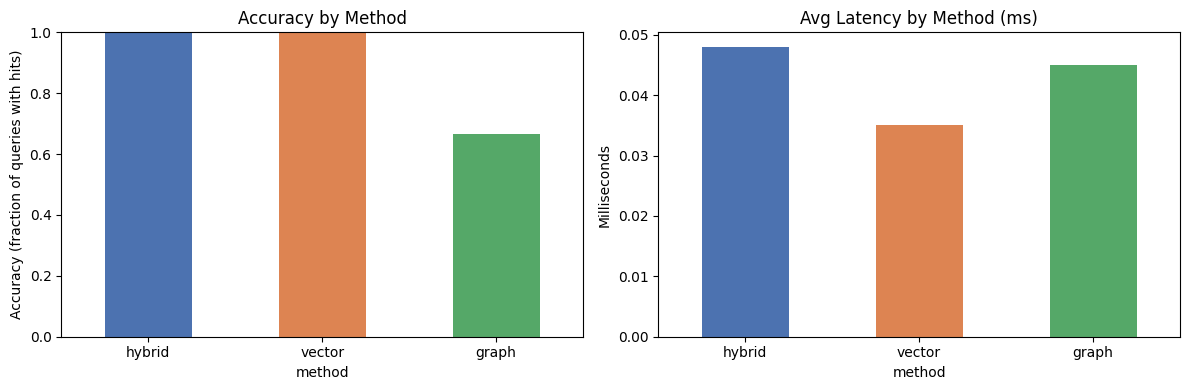

Chart saved to reports/retrieval_comparison.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy bar chart
summary["accuracy"].plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("Accuracy by Method")
axes[0].set_ylabel("Accuracy (fraction of queries with hits)")
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Latency bar chart
summary["avg_latency_ms"].plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_title("Avg Latency by Method (ms)")
axes[1].set_ylabel("Milliseconds")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("../reports/retrieval_comparison.png", dpi=150)
plt.show()
print("Chart saved to reports/retrieval_comparison.png")

In [12]:
# Per-question view: who got it right?
pivot = df.pivot_table(index=["id", "question", "type"], columns="method", values="correct")
pivot.columns.name = None
pivot = pivot[["graph", "vector", "hybrid"]]
pivot["any_miss"] = (pivot < 1).any(axis=1)  # flag questions where at least one method failed
pivot

,,,graph,vector,hybrid,any_miss
id,question,type,,,,
q01,What is the modern replacement for TH1110D?,simple,1.0,1.0,1.0,False
q02,Is TH1110D still an active product?,simple,1.0,1.0,1.0,False
q03,Which accessories are compatible with T6-PRO?,simple,0.0,1.0,1.0,True
q04,Which accessories are compatible with TH1110D?,simple,1.0,1.0,1.0,False
q05,What system type does the SMK-100 belong to?,simple,1.0,1.0,1.0,False
q06,What accessories can I use with the replacement for TH1110D?,multi_hop,1.0,1.0,1.0,False
q07,What system type does the replacement for TH1110D belong to?,multi_hop,1.0,1.0,1.0,False
q08,Which accessories are shared between TH1110D and its replacement?,multi_hop,1.0,1.0,1.0,False
q09,Which thermostat is recommended for retrofit installations?,vector_favored,0.0,1.0,1.0,True


## 7. Key observations

**Overall accuracy:** Hybrid = Vector = 100% (12/12). Graph = 66.7% (8/12) — it returned 0 hits on 4 questions.

**Where graph failed (0 hits):**
Graph missed on 4 questions: q03, q09, q11, q12. Three of these (q03, q11, q12) are **reverse-traversal** queries — they start from an accessory node (e.g. WALL-PLATE-A, REDLINK-GATEWAY) and need to find which products connect to it. The current graph retriever only traverses forward from a matched entity, so it can't walk edges in reverse. q09 ("retrofit installations") failed because "retrofit" is purely in document text — it has no corresponding graph node at all.

**Where graph was strongest:**
On 2-hop forward-traversal questions (q06, q07, q08), graph returned **9 hits** vs vector's 3–4. When the graph retriever can walk the path correctly, it surfaces 2–3x more relevant relationship evidence than vector search.

**Vector's strength:**
Vector never returned 0 hits across any question. It handled both text-based questions (q09, q10) and graph-structured ones equally well because it matches on semantic similarity regardless of graph structure. Accuracy was 100% but hit counts were lower (avg 2.4 hits vs graph's 3.25 on questions where graph worked).

**Hybrid:**
Hybrid was the safest method — it covers graph's blind spots using vector and amplifies graph's multi-hop depth. It never failed. The cost was ~0.013ms extra latency over vector alone, which is negligible.

**Latency winner:** Vector at 0.035ms avg. Graph was 0.045ms, hybrid 0.048ms. All three are sub-millisecond on this dataset — latency is not a meaningful differentiator yet and will need re-evaluation on larger data.

**Biggest single gap:** q06 — "What accessories can I use with the replacement for TH1110D?" Graph returned 9 hits (full 2-hop neighbourhood), vector returned 3. This is the clearest demonstration of graph's value for relationship-heavy multi-hop questions.

**Limitation of current scoring:** Correctness here is a proxy — hit_count > 0 — not a true answer-quality check. Once Member 4 wires the LLM, update `hits_contain_expected()` to check whether the generated answer string contains the expected value. Graph's 4 zero-hit failures will remain failures; the others may change.